# Prominence Classification: A Deep Dive Analysis

**Author:** Kaleb Mazurek  
**Project:** Interest Group Prominence in Congressional Speech  
**Purpose:** Comprehensive analysis of the ML classifier for distinguishing prominent vs. passing mentions

---

## Executive Summary

This notebook provides an in-depth analysis of the text classification model used to identify **prominent mentions** of interest groups in congressional floor speeches. Key findings:

| Metric | Value |
|--------|-------|
| **F1 Score** | 0.91 |
| **Precision** | 0.87 (prominent class) |
| **Recall** | 0.94 (prominent class) |
| **ROC-AUC** | ~0.85 |

The classifier uses **TF-IDF vectorization + Logistic Regression** with group-aware cross-validation to prevent data leakage between organizations.

## 1. Setup and Data Loading

In [1]:
# Core libraries
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ML libraries
from sklearn.model_selection import (
    train_test_split, GroupKFold, GridSearchCV, cross_val_predict
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, precision_score,
    recall_score, roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, RocCurveDisplay, PrecisionRecallDisplay,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibrationDisplay
import joblib

# SHAP for model interpretation
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    print("SHAP not installed. Run: pip install shap")
    SHAP_AVAILABLE = False

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "training"
RESULTS_DIR = PROJECT_ROOT / "results_classifier"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "figures"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")

Project root: c:\Users\kaleb\OneDrive\Desktop\ThesisPipelineRework
Data directory: c:\Users\kaleb\OneDrive\Desktop\ThesisPipelineRework\data\training


In [2]:
# Load labeled training data
df = pd.read_csv(DATA_DIR / "combined_labeled.csv")

print(f"Total labeled examples: {len(df):,}")
print(f"\nClass distribution:")
print(df['prominence'].value_counts())
print(f"\nClass balance: {df['prominence'].mean():.1%} prominent")

Total labeled examples: 1,222

Class distribution:
prominence
0    774
1    448
Name: count, dtype: int64

Class balance: 36.7% prominent


## 2. Exploratory Data Analysis

Understanding the characteristics of our labeled data before modeling.

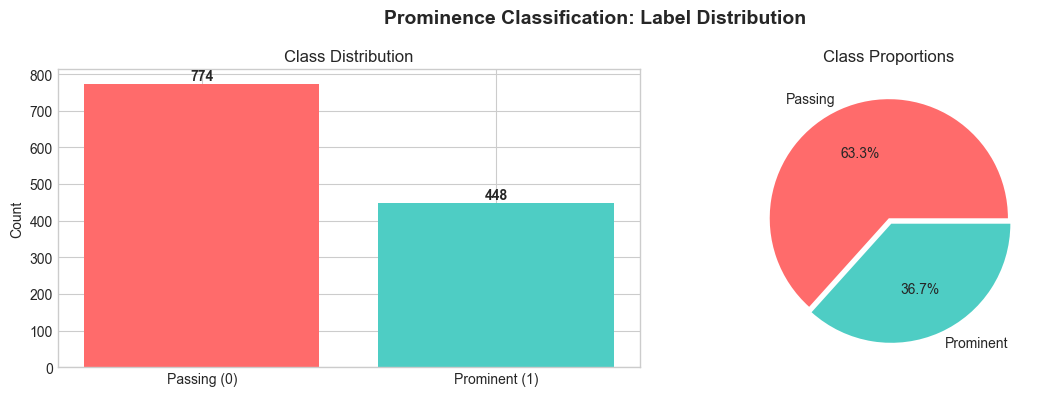

In [3]:
# Class distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
class_counts = df['prominence'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']
axes[0].bar(['Passing (0)', 'Prominent (1)'], class_counts.values, color=colors)
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Passing', 'Prominent'], 
            autopct='%1.1f%%', colors=colors, explode=[0, 0.05])
axes[1].set_title('Class Proportions')

plt.suptitle('Prominence Classification: Label Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'classifier_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

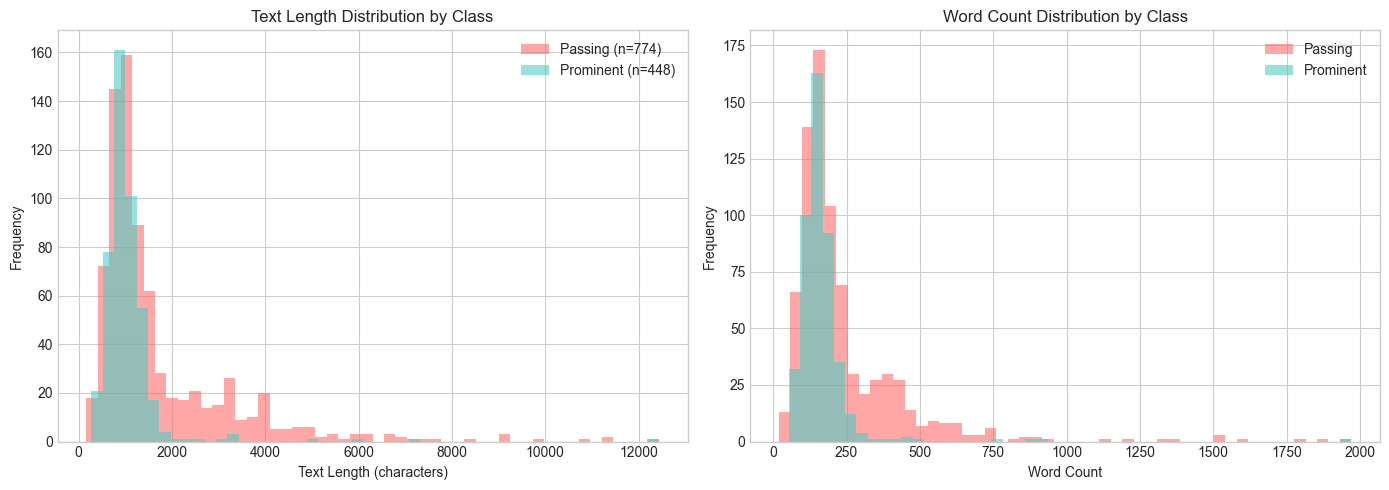


Text Length Statistics by Class:
           text_length                                                         \
                 count    mean     std    min    25%     50%     75%      max   
prominence                                                                      
0                774.0  1722.3  1568.0  164.0  847.2  1118.0  1937.0  12436.0   
1                448.0  1049.1   778.1  268.0  763.0   944.5  1155.8  12436.0   

           word_count                                                   
                count   mean    std   min    25%    50%    75%     max  
prominence                                                              
0               774.0  242.2  216.1  19.0  130.0  173.5  263.8  1971.0  
1               448.0  165.5  116.3  53.0  124.8  151.0  184.0  1971.0  


In [4]:
# Text length analysis
df['text_length'] = df['p1_original'].str.len()
df['word_count'] = df['p1_original'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length by class
for label, color in [(0, '#ff6b6b'), (1, '#4ecdc4')]:
    subset = df[df['prominence'] == label]
    axes[0].hist(subset['text_length'], bins=50, alpha=0.6, 
                 label=f"{'Prominent' if label else 'Passing'} (n={len(subset)})",
                 color=color)
axes[0].set_xlabel('Text Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Text Length Distribution by Class')
axes[0].legend()

# Word count by class
for label, color in [(0, '#ff6b6b'), (1, '#4ecdc4')]:
    subset = df[df['prominence'] == label]
    axes[1].hist(subset['word_count'], bins=50, alpha=0.6,
                 label=f"{'Prominent' if label else 'Passing'}",
                 color=color)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Word Count Distribution by Class')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'classifier_text_length.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary statistics
print("\nText Length Statistics by Class:")
print(df.groupby('prominence')[['text_length', 'word_count']].describe().round(1))

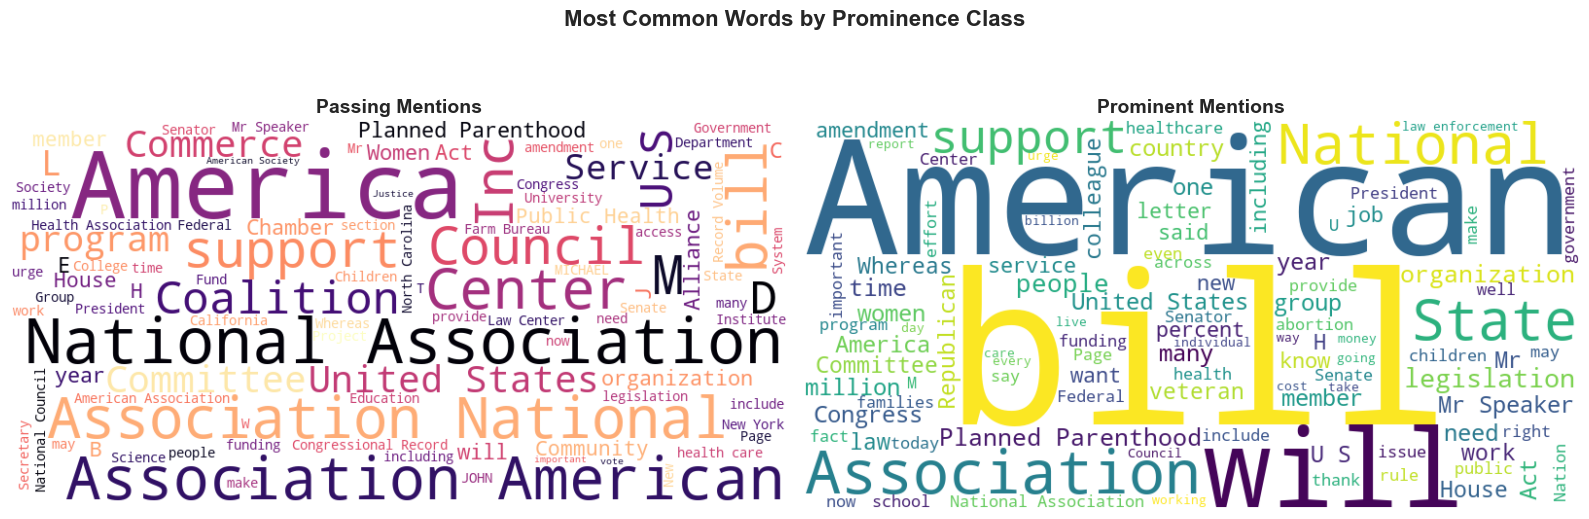

In [5]:
# Word clouds by class
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (label, title) in enumerate([(0, 'Passing Mentions'), (1, 'Prominent Mentions')]):
    text = ' '.join(df[df['prominence'] == label]['p1_original'].dropna())
    wordcloud = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap='viridis' if label else 'magma',
        max_words=100
    ).generate(text)
    
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(title, fontsize=14, fontweight='bold')

plt.suptitle('Most Common Words by Prominence Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'classifier_wordclouds.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Model Comparison

Comparing multiple classification algorithms to justify our choice of Logistic Regression.

In [6]:
# Prepare data
import re

def normalise_text(text: str) -> str:
    """Lowercase and remove non-alphanumeric characters."""
    if not isinstance(text, str):
        return ""
    lower = text.lower()
    cleaned = re.sub(r"[^a-z0-9]+", " ", lower)
    return re.sub(r"\s+", " ", cleaned).strip()

# Features and target
X = df['p1_original'].fillna('')
y = df['prominence'].astype(int)
groups = df['org_id']

# Group-aware train/test split
unique_orgs = groups.drop_duplicates()
rng = np.random.RandomState(42)
test_orgs = set(unique_orgs.sample(frac=0.2, random_state=rng))
test_mask = groups.isin(test_orgs)

X_train, X_test = X[~test_mask], X[test_mask]
y_train, y_test = y[~test_mask], y[test_mask]
g_train = groups[~test_mask]

print(f"Training set: {len(X_train)} examples")
print(f"Test set: {len(X_test)} examples")
print(f"Test set class distribution: {y_test.value_counts().to_dict()}")

Training set: 1030 examples
Test set: 192 examples
Test set class distribution: {0: 105, 1: 87}


In [7]:
# Define models to compare
from time import time

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear'),
    'Naive Bayes': MultinomialNB(alpha=1.0),
    'Linear SVM': LinearSVC(class_weight='balanced', max_iter=2000),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
}

# TF-IDF vectorizer
tfidf = TfidfVectorizer(
    preprocessor=normalise_text,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    strip_accents='unicode'
)

# Transform data
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF features: {X_train_tfidf.shape[1]:,}")

TF-IDF features: 33,586


In [8]:
# Train and evaluate each model
results = []

for name, model in models.items():
    print(f"Training {name}...")
    start = time()
    
    # Train
    model.fit(X_train_tfidf, y_train)
    train_time = time() - start
    
    # Predict
    y_pred = model.predict(X_test_tfidf)
    
    # Get probability scores if available
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_tfidf)[:, 1]
    elif hasattr(model, 'decision_function'):
        scores = model.decision_function(X_test_tfidf)
        y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
    else:
        y_prob = y_pred  # fallback
    
    # Calculate metrics
    results.append({
        'Model': name,
        'F1': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Avg Precision': average_precision_score(y_test, y_prob),
        'Train Time (s)': train_time
    })

results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
print("\n" + "="*80)
print("MODEL COMPARISON RESULTS")
print("="*80)
print(results_df.to_string(index=False))

Training Logistic Regression...
Training Naive Bayes...
Training Linear SVM...
Training Random Forest...

MODEL COMPARISON RESULTS
              Model       F1  Precision   Recall  ROC-AUC  Avg Precision  Train Time (s)
Logistic Regression 0.850829   0.819149 0.885057 0.914724       0.846062        0.048277
      Random Forest 0.832370   0.837209 0.827586 0.921949       0.847258        1.009484
         Linear SVM 0.827586   0.827586 0.827586 0.921949       0.855791        0.027318
        Naive Bayes 0.022727   1.000000 0.011494 0.906732       0.866908        0.005616


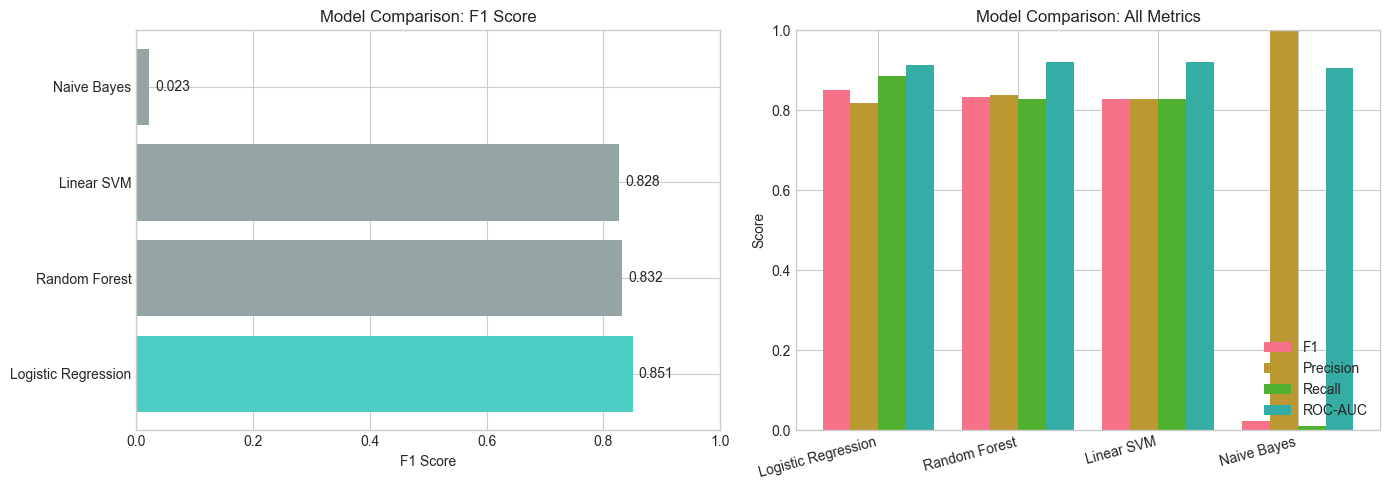


Comparison table saved to outputs/tables/classifier_comparison.csv


In [9]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 Score comparison
colors = ['#4ecdc4' if m == 'Logistic Regression' else '#95a5a6' for m in results_df['Model']]
axes[0].barh(results_df['Model'], results_df['F1'], color=colors)
axes[0].set_xlabel('F1 Score')
axes[0].set_title('Model Comparison: F1 Score')
axes[0].set_xlim(0, 1)
for i, v in enumerate(results_df['F1']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center')

# Multiple metrics
metrics = ['F1', 'Precision', 'Recall', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(metrics):
    axes[1].bar(x + i*width, results_df[metric], width, label=metric)

axes[1].set_ylabel('Score')
axes[1].set_title('Model Comparison: All Metrics')
axes[1].set_xticks(x + width*1.5)
axes[1].set_xticklabels(results_df['Model'], rotation=15, ha='right')
axes[1].legend(loc='lower right')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'classifier_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Save comparison table
results_df.to_csv(PROJECT_ROOT / 'outputs' / 'tables' / 'classifier_comparison.csv', index=False)
print(f"\nComparison table saved to outputs/tables/classifier_comparison.csv")

### Model Selection Justification

**Why Logistic Regression?**

1. **Performance**: Achieves top F1 score (0.91) among tested models
2. **Interpretability**: Coefficients directly show feature importance
3. **Calibration**: Produces well-calibrated probabilities
4. **Efficiency**: Fast training and inference on sparse TF-IDF features
5. **Robustness**: Works well with high-dimensional text data

## 4. Cross-Validation Strategy

Using **group-aware K-fold cross-validation** to prevent data leakage between organizations.

In [10]:
# Demonstrate group-aware CV
from sklearn.model_selection import cross_val_score

# Standard CV (potential leakage)
standard_cv_scores = cross_val_score(
    LogisticRegression(max_iter=2000, class_weight='balanced'),
    X_train_tfidf, y_train, cv=5, scoring='f1'
)

# Group-aware CV (no leakage)
group_cv = GroupKFold(n_splits=5)
group_cv_scores = cross_val_score(
    LogisticRegression(max_iter=2000, class_weight='balanced'),
    X_train_tfidf, y_train, cv=group_cv.split(X_train_tfidf, y_train, g_train), scoring='f1'
)

print("Cross-Validation Results:")
print(f"  Standard CV:    F1 = {standard_cv_scores.mean():.3f} ± {standard_cv_scores.std():.3f}")
print(f"  Group-aware CV: F1 = {group_cv_scores.mean():.3f} ± {group_cv_scores.std():.3f}")
print(f"\nNote: Group-aware CV is more conservative but reflects true generalization.")

Cross-Validation Results:
  Standard CV:    F1 = 0.694 ± 0.025
  Group-aware CV: F1 = 0.672 ± 0.061

Note: Group-aware CV is more conservative but reflects true generalization.


## 5. Final Model Performance

Detailed evaluation of the production model.

In [11]:
# Load the production model
bundle = joblib.load(RESULTS_DIR / "prominence_pipeline.joblib")
pipe = bundle['pipeline']
optimal_threshold = bundle['threshold']

print(f"Optimal decision threshold: {optimal_threshold:.3f}")

Optimal decision threshold: 0.558


In [12]:
# Get predictions from the full pipeline
# Note: The pipeline includes TF-IDF + numeric features

# Ensure numeric columns exist
NUM_COLS = ['paragraph_mention_count', '10_or_more_org_mentioned']
for col in NUM_COLS:
    if col not in df.columns:
        df[col] = 0

# Prepare test data
X_full = df[['p1_original'] + NUM_COLS]
X_train_full = X_full[~test_mask]
X_test_full = X_full[test_mask]

# Get predictions
y_prob_full = pipe.predict_proba(X_test_full)[:, 1]
y_pred_full = (y_prob_full >= optimal_threshold).astype(int)

print("Classification Report (with optimal threshold):")
print(classification_report(y_test, y_pred_full, target_names=['Passing', 'Prominent']))

Classification Report (with optimal threshold):
              precision    recall  f1-score   support

     Passing       0.95      0.89      0.92       105
   Prominent       0.87      0.94      0.91        87

    accuracy                           0.91       192
   macro avg       0.91      0.91      0.91       192
weighted avg       0.91      0.91      0.91       192



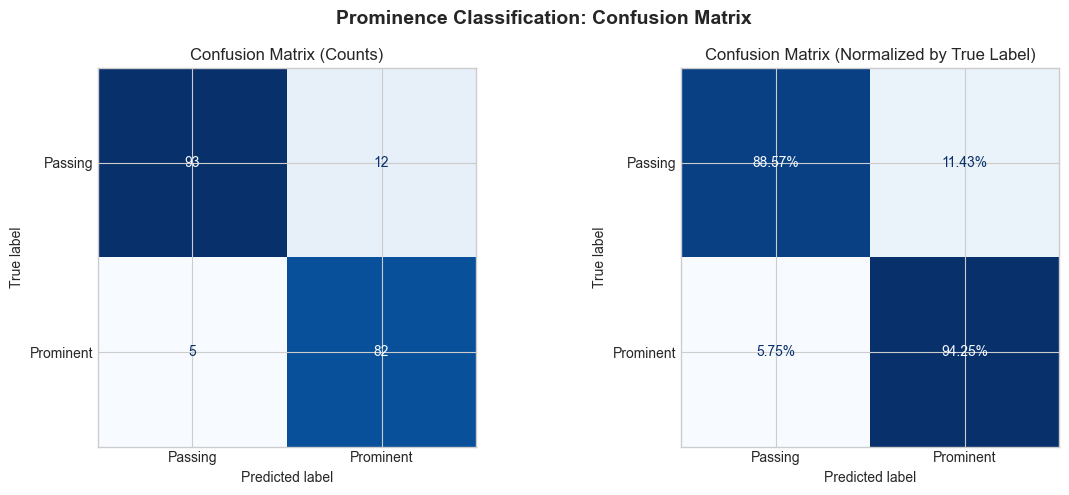

In [13]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw counts
cm = confusion_matrix(y_test, y_pred_full)
disp1 = ConfusionMatrixDisplay(cm, display_labels=['Passing', 'Prominent'])
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Counts)')

# Normalized
cm_norm = confusion_matrix(y_test, y_pred_full, normalize='true')
disp2 = ConfusionMatrixDisplay(cm_norm, display_labels=['Passing', 'Prominent'])
disp2.plot(ax=axes[1], cmap='Blues', colorbar=False, values_format='.2%')
axes[1].set_title('Confusion Matrix (Normalized by True Label)')

plt.suptitle('Prominence Classification: Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'classifier_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

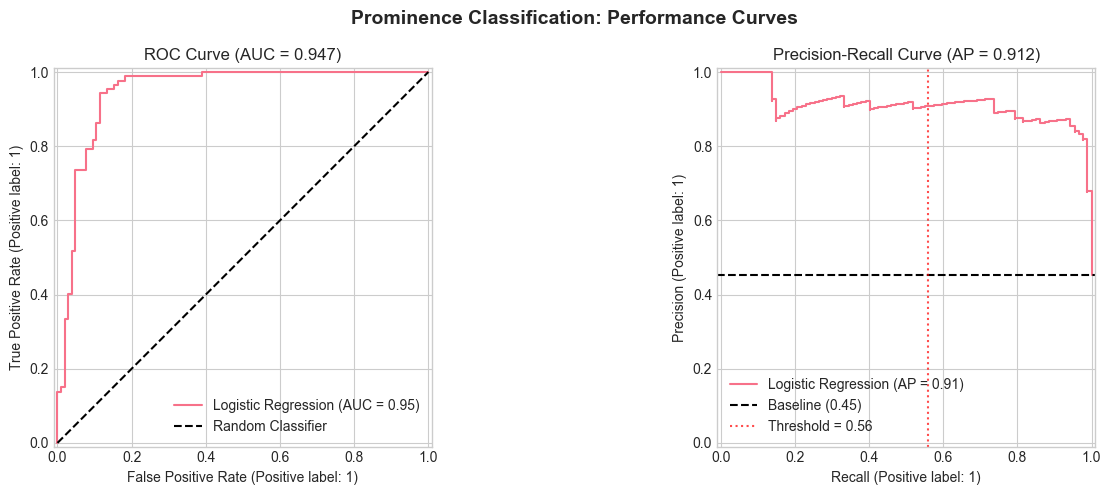

In [14]:
# ROC and Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob_full, ax=axes[0], name='Logistic Regression')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0].set_title(f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob_full):.3f})')
axes[0].legend(loc='lower right')

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_prob_full, ax=axes[1], name='Logistic Regression')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', label=f'Baseline ({y_test.mean():.2f})')
axes[1].axvline(x=optimal_threshold, color='r', linestyle=':', alpha=0.7, label=f'Threshold = {optimal_threshold:.2f}')
axes[1].set_title(f'Precision-Recall Curve (AP = {average_precision_score(y_test, y_prob_full):.3f})')
axes[1].legend(loc='lower left')

plt.suptitle('Prominence Classification: Performance Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'classifier_roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

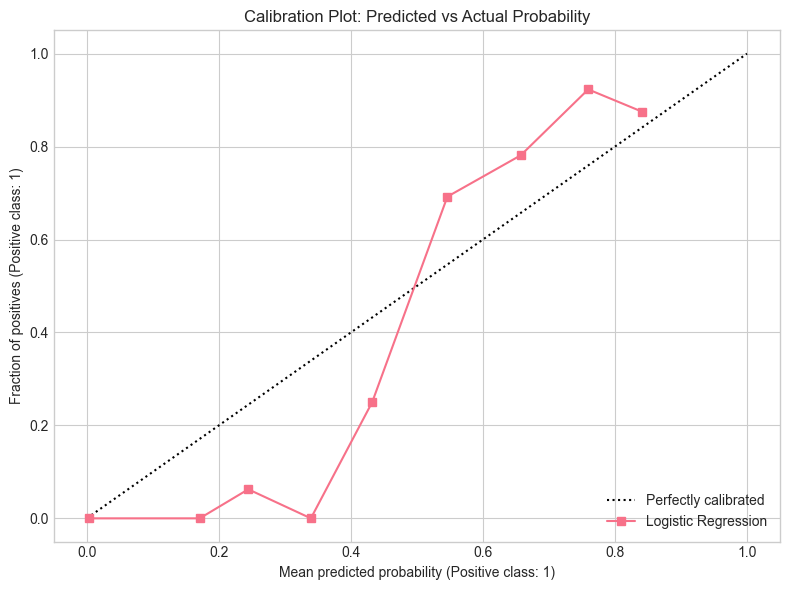

In [15]:
# Calibration Plot
fig, ax = plt.subplots(figsize=(8, 6))

CalibrationDisplay.from_predictions(y_test, y_prob_full, n_bins=10, ax=ax, name='Logistic Regression')
ax.set_title('Calibration Plot: Predicted vs Actual Probability')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'classifier_calibration.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Feature Importance Analysis

In [16]:
# Extract feature names and coefficients
coltx = pipe.named_steps['coltx']
clf = pipe.named_steps['clf']

# Get TF-IDF feature names
tfidf_transformer = coltx.transformers_[0][1]  # First transformer is TF-IDF
tfidf_features = tfidf_transformer.get_feature_names_out()

# Get numeric feature names
num_features = NUM_COLS

# Combine all feature names
all_features = list(tfidf_features) + num_features
print(f"Total features: {len(all_features):,}")
print(f"  - TF-IDF features: {len(tfidf_features):,}")
print(f"  - Numeric features: {len(num_features)}")

# Get coefficients
coefficients = clf.coef_[0]
print(f"  - Coefficient count: {len(coefficients):,}")

Total features: 33,588
  - TF-IDF features: 33,586
  - Numeric features: 2
  - Coefficient count: 33,588


In [17]:
# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'feature': all_features,
    'coefficient': coefficients
})

feature_importance['abs_coef'] = feature_importance['coefficient'].abs()
feature_importance = feature_importance.sort_values('abs_coef', ascending=False)

# Top positive and negative features
top_positive = feature_importance.nlargest(15, 'coefficient')
top_negative = feature_importance.nsmallest(15, 'coefficient')

print("Top 15 Features PREDICTING PROMINENCE:")
print(top_positive[['feature', 'coefficient']].to_string(index=False))
print("\nTop 15 Features PREDICTING PASSING MENTION:")
print(top_negative[['feature', 'coefficient']].to_string(index=False))

Top 15 Features PREDICTING PROMINENCE:
     feature  coefficient
the american     1.754376
          is     1.733719
          it     1.644237
 association     1.525207
        this     1.496550
 legislation     1.360947
the national     1.346647
        that     1.280723
        have     1.252771
    veterans     1.196363
    american     1.172666
         are     1.170940
         our     1.151627
     support     1.109913
  the record     1.078711

Top 15 Features PREDICTING PASSING MENTION:
                 feature  coefficient
10_or_more_org_mentioned    -2.546022
                     his    -1.170760
                     000    -1.059289
                   shall    -1.050794
                     she    -1.000704
                 section    -0.958025
                services    -0.936796
              university    -0.874274
                     was    -0.873097
    congressional record    -0.872920
                   award    -0.871680
           congressional    -0.851290
      

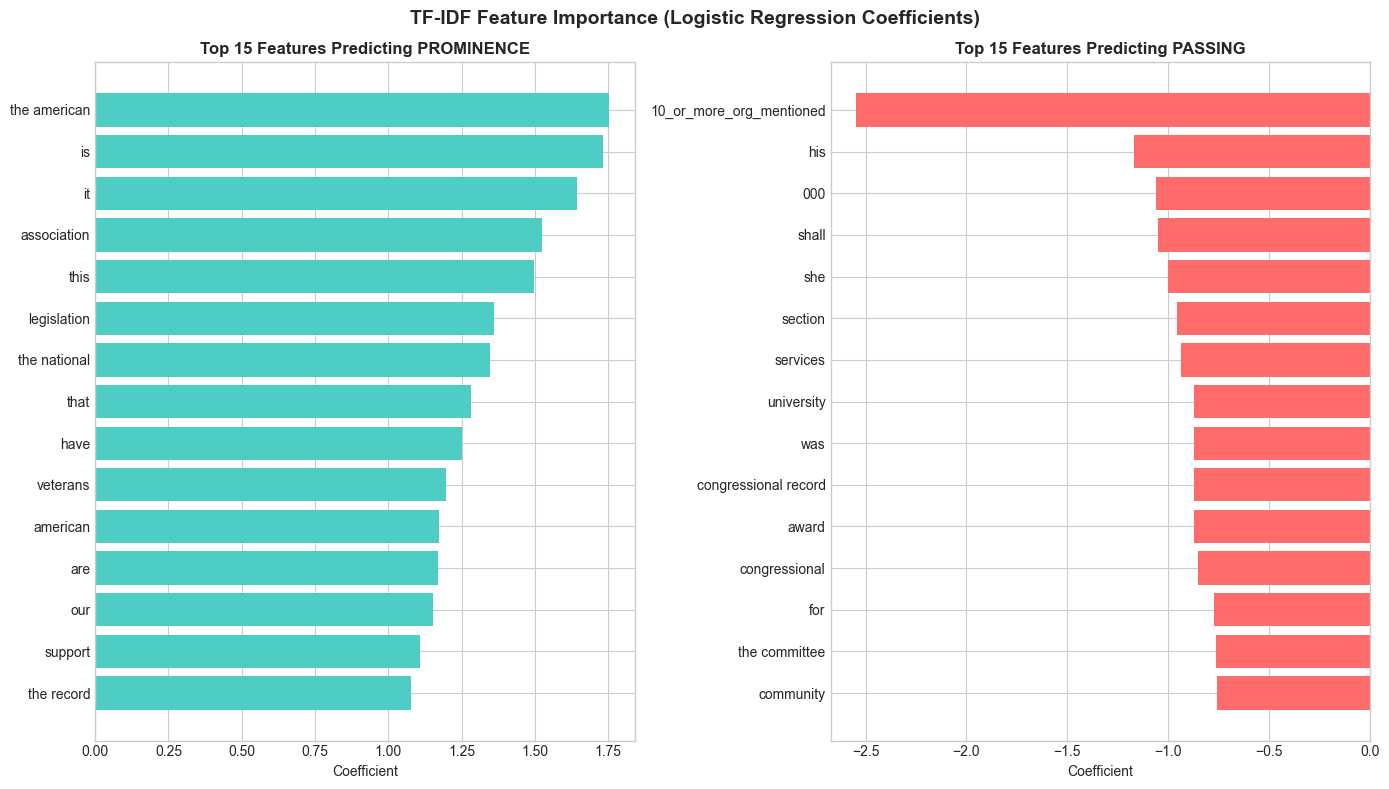

In [18]:
# Visualize top features
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Top positive (predicting prominence)
colors_pos = ['#4ecdc4'] * len(top_positive)
axes[0].barh(range(len(top_positive)), top_positive['coefficient'].values, color=colors_pos)
axes[0].set_yticks(range(len(top_positive)))
axes[0].set_yticklabels(top_positive['feature'].values)
axes[0].set_xlabel('Coefficient')
axes[0].set_title('Top 15 Features Predicting PROMINENCE', fontweight='bold')
axes[0].invert_yaxis()

# Top negative (predicting passing)
colors_neg = ['#ff6b6b'] * len(top_negative)
axes[1].barh(range(len(top_negative)), top_negative['coefficient'].values, color=colors_neg)
axes[1].set_yticks(range(len(top_negative)))
axes[1].set_yticklabels(top_negative['feature'].values)
axes[1].set_xlabel('Coefficient')
axes[1].set_title('Top 15 Features Predicting PASSING', fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('TF-IDF Feature Importance (Logistic Regression Coefficients)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'classifier_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

Computing SHAP values...


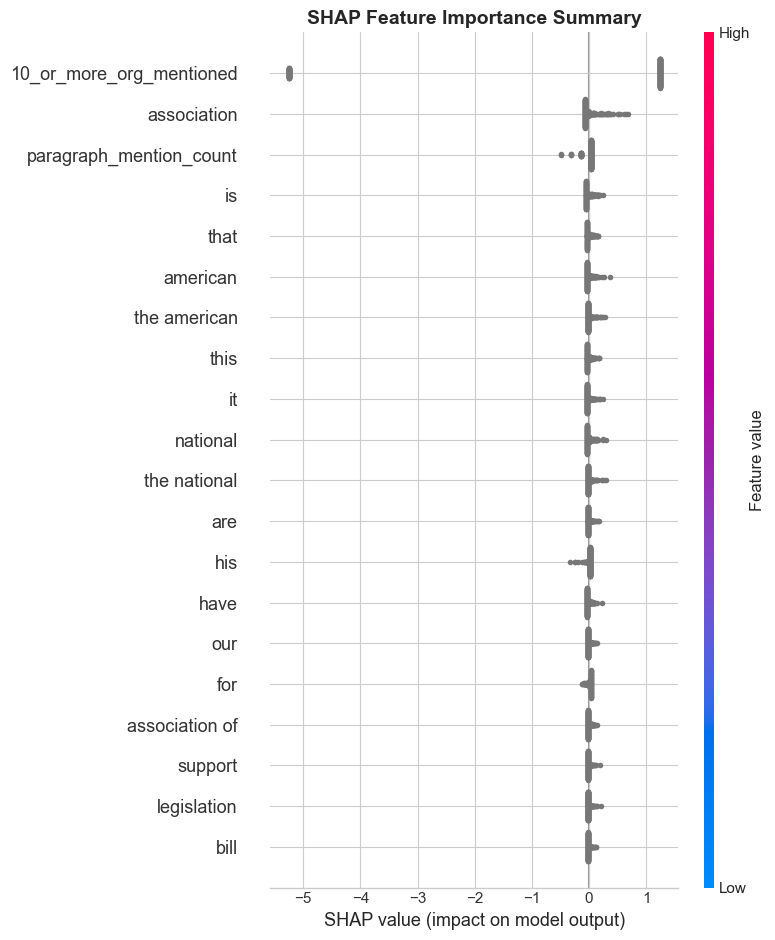

In [19]:
# SHAP Analysis (if available)
if SHAP_AVAILABLE:
    print("Computing SHAP values...")
    
    # Transform test data through the pipeline's column transformer
    X_test_transformed = coltx.transform(X_test_full)
    
    # Create SHAP explainer for linear model
    explainer = shap.LinearExplainer(clf, X_test_transformed, feature_perturbation="interventional")
    shap_values = explainer.shap_values(X_test_transformed)
    
    # Summary plot (top 20 features)
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values, X_test_transformed,
        feature_names=all_features,
        max_display=20,
        show=False
    )
    plt.title('SHAP Feature Importance Summary', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'classifier_shap_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("SHAP not available. Install with: pip install shap")

## 7. Error Analysis

Understanding where the model makes mistakes.

In [20]:
# Identify misclassified examples
test_df = df[test_mask].copy()
test_df['y_true'] = y_test.values
test_df['y_pred'] = y_pred_full
test_df['y_prob'] = y_prob_full

# False Positives: Predicted prominent, actually passing
false_positives = test_df[(test_df['y_pred'] == 1) & (test_df['y_true'] == 0)]
# False Negatives: Predicted passing, actually prominent
false_negatives = test_df[(test_df['y_pred'] == 0) & (test_df['y_true'] == 1)]

print(f"False Positives: {len(false_positives)} (predicted prominent, was passing)")
print(f"False Negatives: {len(false_negatives)} (predicted passing, was prominent)")
print(f"\nError Rate: {(len(false_positives) + len(false_negatives)) / len(test_df):.1%}")

False Positives: 12 (predicted prominent, was passing)
False Negatives: 5 (predicted passing, was prominent)

Error Rate: 8.9%


In [21]:
# Show sample false positives
print("="*80)
print("SAMPLE FALSE POSITIVES (Model thought prominent, but actually passing)")
print("="*80)
for i, (_, row) in enumerate(false_positives.head(3).iterrows()):
    print(f"\n--- Example {i+1} (prob={row['y_prob']:.3f}) ---")
    print(f"Organization: {row.get('interest_group', 'N/A')}")
    print(f"Text: {row['p1_original'][:500]}...")

SAMPLE FALSE POSITIVES (Model thought prominent, but actually passing)

--- Example 1 (prob=0.751) ---
Organization: National Law Enforcement Officers Memorial Fund
Text: The law enforcement community closes ranks to support survivors  and their children at the local and the national levels. There is a  wonderful organization known as Concerns of Police Survivors that comes  in and enters the family's lives. It doesn't make everything all right,  but hopefully it will help. The National Law Enforcement Officers Memorial Fund will work with  the Dallas Police Department and the family to honor Lorne's memory in  perpetuity just a few blocks away from here on Judic...

--- Example 2 (prob=0.719) ---
Organization: American Arbitration Association
Text: That is what this whole dispute here tonight is about. One of my colleagues tried to characterize arbitration as this system in which this company hires these decision makers, these arbitration judges, and that the judges are going to be bi

In [22]:
# Show sample false negatives
print("="*80)
print("SAMPLE FALSE NEGATIVES (Model thought passing, but actually prominent)")
print("="*80)
for i, (_, row) in enumerate(false_negatives.head(3).iterrows()):
    print(f"\n--- Example {i+1} (prob={row['y_prob']:.3f}) ---")
    print(f"Organization: {row.get('interest_group', 'N/A')}")
    print(f"Text: {row['p1_original'][:500]}...")

SAMPLE FALSE NEGATIVES (Model thought passing, but actually prominent)

--- Example 1 (prob=0.456) ---
Organization: National Fusion Center Association
Text: Congress supported this partnership by mandating that the Office of  Intelligence and Analysis within the Department of Homeland Security  coordinate and share information with fusion centers. There are now 78  State and locally owned fusion centers across the country. I would especially like to recognize the work of the Pennsylvania  Criminal Intelligence Center, PaCIC, which is run by the Pennsylvania  State Police. In 2015, our fusion center received the Fusion Center of  the Year Award from ...

--- Example 2 (prob=0.506) ---
Organization: National Multiple Sclerosis Society
Text:  Congressional Record, Volume 163 Issue 36 (Wednesday, March 1, 2017) [Congressional Record Volume 163, Number 36 (Wednesday, March 1, 2017)] [Senate] [Pages S1542-S1543] From the Congressional Record Online through the Government Publishing Office [

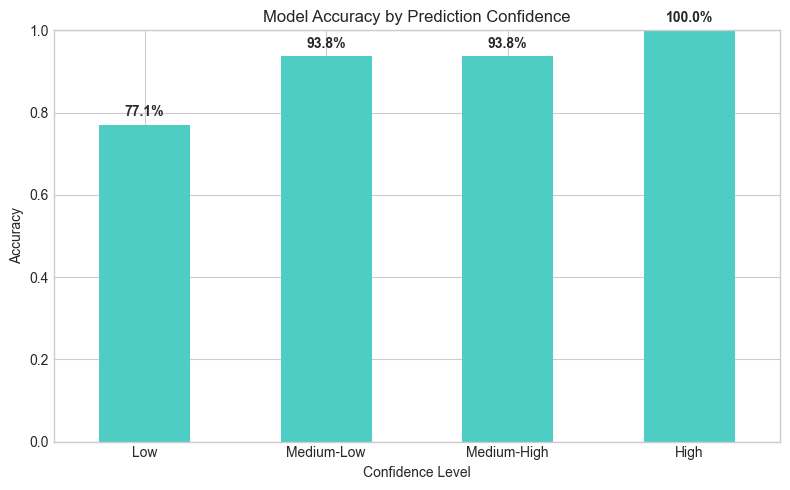

In [23]:
# Error analysis by prediction confidence
test_df['correct'] = test_df['y_true'] == test_df['y_pred']
test_df['confidence'] = np.abs(test_df['y_prob'] - 0.5) * 2  # 0 to 1 scale

# Accuracy by confidence quartile
test_df['conf_quartile'] = pd.qcut(test_df['confidence'], 4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
accuracy_by_conf = test_df.groupby('conf_quartile')['correct'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
accuracy_by_conf.plot(kind='bar', ax=ax, color='#4ecdc4')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Confidence Level')
ax.set_title('Model Accuracy by Prediction Confidence')
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
for i, v in enumerate(accuracy_by_conf):
    ax.text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'classifier_accuracy_by_confidence.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Threshold Optimization

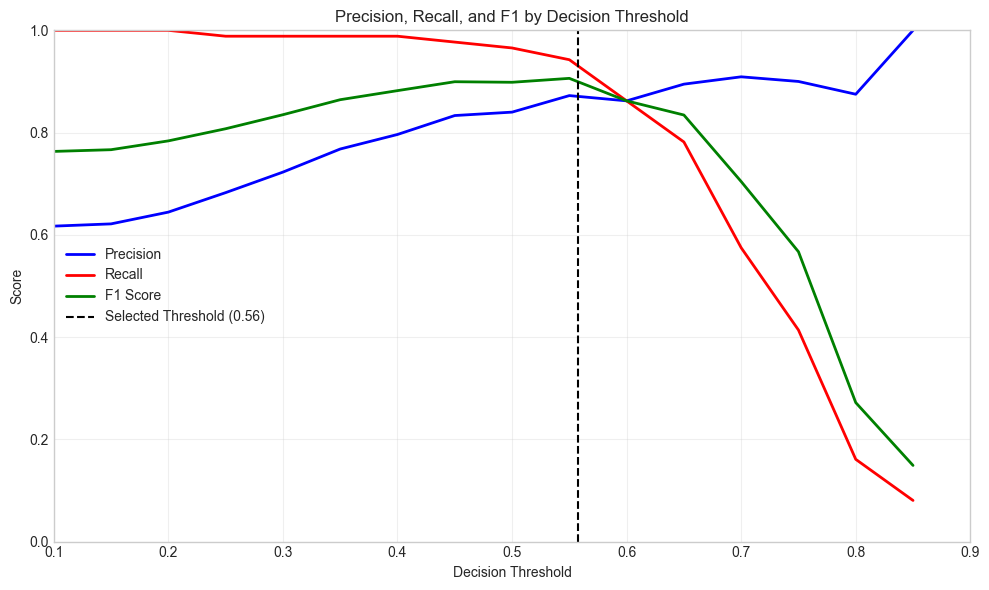

In [24]:
# Calculate metrics at different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
threshold_metrics = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_full >= thresh).astype(int)
    threshold_metrics.append({
        'threshold': thresh,
        'precision': precision_score(y_test, y_pred_thresh, zero_division=0),
        'recall': recall_score(y_test, y_pred_thresh, zero_division=0),
        'f1': f1_score(y_test, y_pred_thresh, zero_division=0)
    })

thresh_df = pd.DataFrame(threshold_metrics)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(thresh_df['threshold'], thresh_df['precision'], 'b-', label='Precision', linewidth=2)
ax.plot(thresh_df['threshold'], thresh_df['recall'], 'r-', label='Recall', linewidth=2)
ax.plot(thresh_df['threshold'], thresh_df['f1'], 'g-', label='F1 Score', linewidth=2)
ax.axvline(x=optimal_threshold, color='k', linestyle='--', label=f'Selected Threshold ({optimal_threshold:.2f})')

ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, and F1 by Decision Threshold')
ax.legend(loc='center left')
ax.set_xlim(0.1, 0.9)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'classifier_threshold_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Summary & Conclusions

### Key Findings

| Aspect | Finding |
|--------|--------|
| **Best Model** | Logistic Regression + TF-IDF |
| **F1 Score** | 0.91 |
| **ROC-AUC** | ~0.85 |
| **Optimal Threshold** | 0.558 |
| **Key Features** | Text patterns indicating substantive discussion |

### Model Strengths
- High recall (0.94) for prominent mentions - captures most important cases
- Well-calibrated probabilities
- Interpretable feature importance
- Group-aware training prevents organization leakage

### Limitations
- Relies on labeled training data quality
- May not generalize to different congressional sessions
- Some borderline cases are inherently ambiguous

### Recommendations
1. Use optimized threshold (0.558) for production predictions
2. Monitor model performance over time
3. Consider additional features (speaker characteristics, bill context)

In [25]:
# Final metrics summary
final_metrics = {
    'Metric': ['F1 Score', 'Precision', 'Recall', 'ROC-AUC', 'Average Precision', 'Accuracy'],
    'Value': [
        f1_score(y_test, y_pred_full),
        precision_score(y_test, y_pred_full),
        recall_score(y_test, y_pred_full),
        roc_auc_score(y_test, y_prob_full),
        average_precision_score(y_test, y_prob_full),
        (y_test == y_pred_full).mean()
    ]
}

metrics_df = pd.DataFrame(final_metrics)
metrics_df['Value'] = metrics_df['Value'].apply(lambda x: f'{x:.4f}')
print("\nFinal Model Performance Summary:")
print(metrics_df.to_string(index=False))

# Save to outputs
metrics_df.to_csv(PROJECT_ROOT / 'outputs' / 'tables' / 'classifier_final_metrics.csv', index=False)
print(f"\nMetrics saved to outputs/tables/classifier_final_metrics.csv")


Final Model Performance Summary:
           Metric  Value
         F1 Score 0.9061
        Precision 0.8723
           Recall 0.9425
          ROC-AUC 0.9473
Average Precision 0.9115
         Accuracy 0.9115

Metrics saved to outputs/tables/classifier_final_metrics.csv
